# Diabetes Prediction using Artificial Neural Network (ANN)

This notebook builds a binary classification model using a simple Artificial Neural Network (MLP) to predict whether a patient has diabetes based on diagnostic measurements.

## Dataset: Pima Indians Diabetes Database

The dataset contains medical diagnostic data for female patients of Pima Indian heritage aged 21 years or older.

### Features (Input Variables):
- **Pregnancies**: Number of times pregnant
- **Glucose**: Plasma glucose concentration over 2 hours in an oral glucose tolerance test
- **BloodPressure**: Diastolic blood pressure (mm Hg)
- **SkinThickness**: Triceps skin fold thickness (mm)
- **Insulin**: 2-Hour serum insulin (mu U/ml)
- **BMI**: Body mass index (weight in kg/(height in m)^2)
- **DiabetesPedigreeFunction**: Diabetes pedigree function (a genetic risk score)
- **Age**: Age in years

### Target Variable:
- **Outcome**: Binary classification (0 = No diabetes, 1 = Diabetes)

## Model Goal

Train a feedforward neural network (ANN) to perform **binary classification** on the diabetes dataset. The model predicts the probability of diabetes onset given the 8 input features.

**Architecture**:
- Input layer: 8 neurons (one per feature)
- Hidden layer 1: 64 neurons with ReLU activation
- Hidden layer 2: 32 neurons with ReLU activation
- Output layer: 1 neuron with Sigmoid activation (binary probability)

## 1. Setup and Imports

In [21]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split

# Set random seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

## 2. Load and Explore the Dataset

In [22]:
# Load the diabetes dataset from the local Week 3 directory
# The dataset contains 768 patient records with 8 features and 1 binary target
dataset = pd.read_csv("diabetes.csv", encoding="utf-8")

In [23]:
# Display the first 5 rows to understand the data structure
dataset.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [24]:
# Check the dataset dimensions: (rows, columns)
# 768 samples, 9 columns (8 features + 1 target)
dataset.shape

(768, 9)

## 3. Data Preprocessing

In [25]:
# Separate features (X) from target (Y)
# X contains columns 0-7 (all 8 input features)
# Y contains column 8 (the binary Outcome)
X = dataset.iloc[:, 0:8].values
Y = dataset.iloc[:, 8].values

In [26]:
# Verify the shape of the feature matrix: 768 samples, 8 features
X.shape

(768, 8)

In [27]:
# Verify the shape of the target vector: 768 labels
Y.shape

(768,)

In [28]:
# Split the data into training (70%) and testing (30%) sets
# The test set will be held out for final evaluation only
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.30, random_state=42)

In [29]:
# Further split the training data into training (80%) and validation (20%) sets
# The validation set is used to monitor overfitting during training
X_train, X_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.2, random_state=42)

## 4. Build the Neural Network Model

In [30]:
# Create a Sequential model (layers stacked linearly)
model = Sequential()

# Hidden Layer 1: 64 neurons, ReLU activation, input shape = 8 features
model.add(Dense(64, input_shape=(8,), activation='relu'))

# Hidden Layer 2: 32 neurons, ReLU activation
model.add(Dense(32, activation='relu'))

# Output Layer: 1 neuron, Sigmoid activation for binary classification
# Outputs a probability between 0 and 1 (threshold at 0.5)
model.add(Dense(1, activation='sigmoid'))

/home/You/Desktop/Extract/Level2-summer-training/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [31]:
# Display the model architecture with parameter counts
# Total params = (8*64 + 64) + (64*32 + 32) + (32*1 + 1) = 512+64 + 2048+32 + 32+1 = 2689
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,689 (10.50 KB)

 Trainable params: 2,689 (10.50 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Compile and Train the Model

In [32]:
# Compile the model with:
# - loss='binary_crossentropy': appropriate for binary classification
# - optimizer='adam': adaptive learning rate optimization
# - metrics=['accuracy']: track accuracy during training
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train the model for 100 epochs with batch size of 10
# validation_data is used to evaluate performance on unseen data after each epoch
# This helps detect overfitting early
hist = model.fit(X_train, y_train,
                 validation_data=(X_val, y_val),
                 epochs=100,
                 batch_size=10,
                 verbose=1)

Epoch 1/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5897 - loss: 1.2361 - val_accuracy: 0.6204 - val_loss: 0.7580
Epoch 2/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6457 - loss: 0.8175 - val_accuracy: 0.6111 - val_loss: 0.8641
Epoch 3/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6364 - loss: 0.8785 - val_accuracy: 0.5833 - val_loss: 0.8879
Epoch 4/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6317 - loss: 0.8269 - val_accuracy: 0.5833 - val_loss: 0.8251
Epoch 5/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6364 - loss: 0.8152 - val_accuracy: 0.5741 - val_loss: 0.9883
Epoch 6/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6434 - loss: 0.8530 - val_accuracy: 0.6111 - val_loss: 1.0045
Epoch 7/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6434 - loss: 0.8409 - val_accuracy: 0.6296 - val_loss: 1.1193
Epoch 8/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6364 - loss: 0.8975 - val_accuracy: 0.6574 - v

## 6. Visualize Training Progress

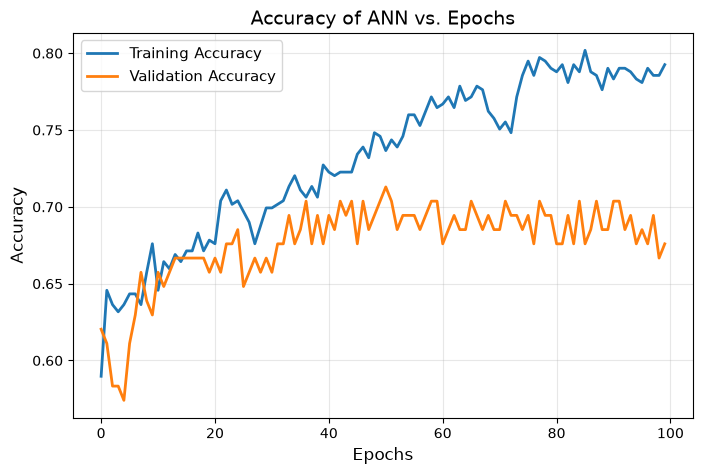

In [33]:
# Plot training and validation accuracy over epochs
# If training accuracy keeps increasing but validation accuracy plateaus or drops, the model is overfitting
plt.figure(figsize=(8, 5))
plt.plot(hist.history['accuracy'], label='Training Accuracy', linewidth=2)
plt.plot(hist.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
plt.title('Accuracy of ANN vs. Epochs', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

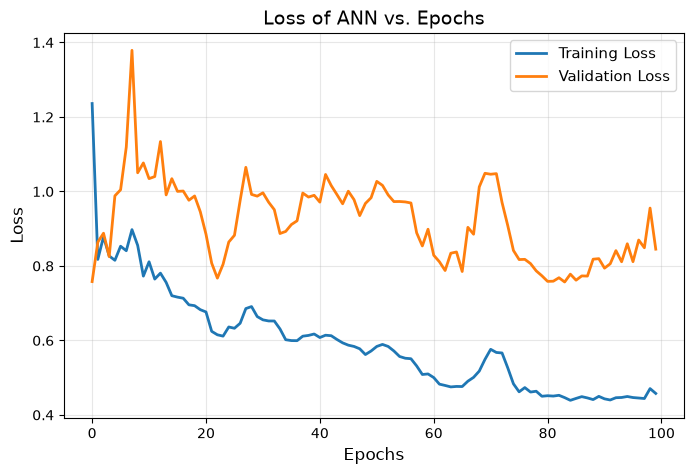

In [34]:
# Plot training and validation loss over epochs
# Both losses should decrease; divergence indicates overfitting
plt.figure(figsize=(8, 5))
plt.plot(hist.history['loss'], label='Training Loss', linewidth=2)
plt.plot(hist.history['val_loss'], label='Validation Loss', linewidth=2)
plt.title('Loss of ANN vs. Epochs', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

## 7. Save the Trained Model

The model is saved locally in the Week 3 directory so it can be loaded later without retraining.

In [35]:
# Save the trained model to the local Week 3 directory
# The .keras format preserves the architecture, weights, and training config
model.save("diabetes_learned_model.keras")

## 8. Load the Saved Model and Make Predictions

Demonstrates how to reload the saved model and use it for inference on new data.

In [36]:
# Load the saved model from the local file
loaded_model = tf.keras.models.load_model("diabetes_learned_model.keras")

In [37]:
# Verify the loaded model has the same architecture as the original
loaded_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,069 (31.52 KB)

 Trainable params: 2,689 (10.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 5,380 (21.02 KB)

In [38]:
# Sample input data for a single prediction
# Format: [Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age]
sample_input = [[1, 80, 80, 20, 50, 50, 0.02, 20]]

# Convert to numpy array as required by the model
sample_input_np = np.array(sample_input)

# Get the predicted probability (between 0 and 1)
prediction_prob = loaded_model.predict(sample_input_np)
print(f"Predicted probability of diabetes: {prediction_prob[0][0]:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Predicted probability of diabetes: 0.0007


In [39]:
# Convert the probability to a binary class label (0 or 1) using 0.5 threshold
# Round to nearest integer: >= 0.5 → 1 (diabetic), < 0.5 → 0 (non-diabetic)
binary_predictions = np.round(prediction_prob).astype(int)
print(f"Binary prediction (0=No Diabetes, 1=Diabetes): {binary_predictions[0][0]}")

Binary prediction (0=No Diabetes, 1=Diabetes): 0


In [40]:
# Evaluate the loaded model on the held-out test set
# This gives an unbiased estimate of the model's real-world performance
model_loss, model_accuracy = loaded_model.evaluate(x_test, y_test, verbose=0)
print(f"Test Accuracy: {model_accuracy:.4f}")
print(f"Test Loss:     {model_loss:.4f}")

Test Accuracy: 0.6970
Test Loss:     0.9662


---

#  Exercise: Banknote Authentication using ANN

Now it's your turn! Apply the same ANN pipeline to a **different binary classification dataset**.

## Dataset: Banknote Authentication

This dataset contains features extracted from images of genuine and forged banknote specimens. Your goal is to build a classifier that determines whether a banknote is **authentic (0)** or **forged (1)**.

### Features (Input Variables):
- **Variance**: Variance of Wavelet Transformed image
- **Skewness**: Skewness of Wavelet Transformed image
- **Curtosis**: Curtosis of Wavelet Transformed image
- **Entropy**: Entropy of the image

### Target Variable:
- **Class**: Binary classification (0 = Authentic, 1 = Forged)

### Details:
- **Total samples**: 1372
- **Features**: 4 numerical features
- **Task**: Binary classification (predict whether a banknote is forged)

### Your Goal:
Complete the code below to:
1. Load the dataset
2. Separate features (X) and target (Y)
3. Split into train, validation, and test sets (70% train, 30% test, then 80%/20% split of train into train/val)
4. Build, compile, train, and evaluate your own ANN model

In [ ]:
# ===== YOUR TURN! Complete the TODOs below =====

# TODO 1: Import necessary libraries
# Hint: You'll need numpy, pandas, train_test_split from sklearn,
# Sequential / Dense from tensorflow.keras, and matplotlib
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense


# TODO 2: Load the banknote authentication dataset
# The file is named 'banknote_authentication.csv' in the Week 3 directory
# Hint: Use pd.read_csv()
dataset = ...  # ← Fill this in


# TODO 3: Separate features (X) and target (Y)
# The dataset has 5 columns: columns 0-3 are features, column 4 is the target 'Class'
# Use .iloc to extract them (similar to what we did with the diabetes dataset)
X = ...   # ← Fill this in (all rows, columns 0 through 3)
Y = ...   # ← Fill this in (all rows, column 4)


# TODO 4: Split the data into training (70%) and testing (30%) sets
# Use train_test_split with test_size=0.30 and random_state=42
x_train, x_test, y_train, y_test = ...  # ← Fill this in


# TODO 5: Further split the training data into training (80%) and validation (20%) sets
# Use train_test_split again, this time on x_train/y_train with test_size=0.2
X_train, X_val, y_train, y_val = ...  # ← Fill this in


# TODO 6: Print the shapes of your training, validation, and test sets
# Use .shape on each array
print("Training set shape:", ...)   # X_train.shape
print("Validation set shape:", ...) # X_val.shape
print("Test set shape:", ...)       # x_test.shape


# TODO 7: Build a Sequential ANN model
# Use a similar architecture to the diabetes notebook:
# - Hidden layer 1: 64 neurons, ReLU activation (input_shape=(4,), since we have 4 features)
# - Hidden layer 2: 32 neurons, ReLU activation
# - Output layer: 1 neuron, Sigmoid activation
model = ...   # ← Create Sequential()
# model.add(...)  # Hidden layer 1
# model.add(...)  # Hidden layer 2
# model.add(...)  # Output layer


# TODO 8: Compile the model
# Use loss='binary_crossentropy', optimizer='adam', metrics=['accuracy']
# model.compile(...)


# TODO 9: Display the model summary
# model.summary()


# TODO 10: Train the model for 50 epochs with batch_size=10
# Pass validation_data=(X_val, y_val) and verbose=1
# hist = model.fit(...)


# TODO 11: Plot the training and validation accuracy over epochs
# Copy the plotting code from the diabetes notebook (cell 13)


# TODO 12: Evaluate the model on the test set and print the test accuracy
# model_loss, model_accuracy = model.evaluate(x_test, y_test, verbose=0)
# print(f"Test Accuracy: {model_accuracy:.4f}")